<h1 align="center">Organization Info</h1>

**Дополнительный материал для выполнения дз**:
- Лукашин Ю.П. Адаптивные методы краткосрочного прогнозирования временных рядов. Финансы и статистика. 2003, главы 1,4,5,7.
- https://otexts.com/fpp2/expsmooth.html


<h1 align="center">Check Questions (5%)</h1>

Ответе на вопросы своими словами (загугленный материал надо пересказать), ответ обоснуйте (напишите и ОБЪЯСНИТЕ формулки если потребуется), если не выходит, то вернитесь к лекции дополнительным материалам:

**Вопрос 1**: Опишите, как изменяется адаптивная способность алгоритма Simple Exponential Smoothing при изменении параметра $\alpha$ от 0 до 1.

<Ответ>

**Вопрос 2**: Докажите равенство выражений в $\color{green}{рекуррентной~форме}$ и в $\color{red} {форме~корректировки~на~ошибку}$ для модели Тейла-Вейджа.

$$ \hat y_{t+d} = \hat l_t + \hat b_t\cdot d + \hat s_{t+(d\mod p)-p}. $$

$$ \hat l_t =  \color{green}{\alpha (y_t - \hat s_{t-p}) + (1-\alpha) (\hat l_{t-1} + \hat b_{t-1} )}=\color{red}{\hat l_{t-1} + \hat b_{t-1} + \alpha e_t};$$

$$\hat b_t =  \color{green}{\beta (\hat l_{t} - \hat l_{t-1} ) + (1-\beta) \hat b_{t-1} } = \color{red}{\hat b_{t-1} + \alpha\beta e_t};$$

$$ \hat s_t = \color{green}{\gamma (y_t-\hat l_{t}) + (1-\gamma) \hat s_{t-p} }= \color{red}{\hat s_{t-p} + \gamma(1-\alpha)e_t}.$$

где
$e_t = y_t-\hat y_t$


<Ответ>

**Вопрос 3**: Каким следует выбрать параметр сглаживания тренда $\beta$ в модели Хольта (линейный тренд) в случае, когда вы предсказываете временной ряд 1) с плавно меняющимя трендом; 2) стохастически меняющися трендом?

<Ответ>


<h1 align="center"> Practice</h1>

#1. reading data (5%)


In [ ]:
# start with this code
import pandas as pd
import numpy as np
from utils import InitExponentialSmoothing, build_forecast, plot_ts_forecast
from utils import qualityMAPE

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [ ]:
import os
import numpy as np
import math
import scipy as sc
import pandas as pd
#import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.express as px
#from plotly.subplots import make_subplots
pd.options.plotting.backend = "plotly"


# Initialized Exponential Smoothing
# x <array Tx1>- pandas time series,
# h <scalar> - forecasting delay
# Params <dict> - dictionary with
#    alpha <scalar in [0,1]> - smoothing parameter
#    AdaptationPeriod <int> - length of Adaptation period in timestamps

def InitExponentialSmoothing(x, h, Params):
    T = len(x)
    alpha = Params['alpha']
    AdaptationPeriod=Params['AdaptationPeriod']
    FORECAST = [np.NaN]*(T+h)
    if alpha>1:
        w.warn('Alpha can not be more than 1')
        #alpha = 1
        return FORECAST
    if alpha<0:
        w.warn('Alpha can not be less than 0')
        #alpha = 0
        return FORECAST
    y = x[0]
    t0=0
    for t in range(0, T):
        if not math.isnan(x[t]):
            if math.isnan(y):
                y=x[t]
                t0=t
            if (t-t0+1)<AdaptationPeriod:
                y = y*(1-alpha*(t-t0+1)/(AdaptationPeriod)) + alpha*(t-t0+1)/(AdaptationPeriod)*x[t]
            y = y*(1-alpha) + alpha*x[t]
            #else do not nothing
        FORECAST[t+h] = y
    return FORECAST

# Simple Exponential Smoothing
# x <array Tx1>- time series,
# h <scalar> - forecasting delay
# Params <dict> - dictionary with
#    alpha <scalar in [0,1]> - smoothing parameter

def SimpleExponentialSmoothing(x, h=1, params={'alpha':0.1}, freq = None):
    T = len(x)
    alpha = params['alpha']

    # retrieve date frequency in ts
    if freq is None:
      freq = pd.infer_freq(x.index)


    # prepare Forecast pd.Series to put forecasted values in it
    forecast = pd.Series(index = x.index.append(pd.date_range(x.index[-1], periods=h+1, freq=freq)[1:]), name = 'fcst '+x.name)

    # some checks for alpha parameter
    if alpha>1:
        w.warn('Alpha can not be more than 1')
        #alpha = 1
        return forecast
    if alpha<0:
        w.warn('Alpha can not be less than 0')
        #alpha = 0
        return forecast

    # initialization
    y = x.iloc[0]

    # forecast all ts step-by-step
    for cntr in range(T):
        if not math.isnan(x.iloc[cntr]):
            if math.isnan(y):
                y=x.iloc[cntr]
            y = alpha*x.iloc[cntr] + (1-alpha)*y  # = y + alpha*(x[cntr]-y)
        #else do not nothing
        forecast.iloc[cntr+h] = y # academic forecast, for ML training
        # forecast_production = forecast
        # forecast_production.iloc[T:] = forecast_production.iloc[T+h] # production forecast

    return forecast #, forecst.iloc[T+h]

def HoltExponentialSmoothing(x, h, Params):
    T = len(x)
    alpha = Params['alpha']
    beta = Params['beta']
    AdaptationPeriod = Params['AdaptationPeriod']

    FORECAST = [np.nan]*(T+h)
    # if alpha>1:
    #     w.warn('Alpha can not be more than 1')
    #     #alpha = 1
    #     return FORECAST
    # if alpha<0:
    #     w.warn('Alpha can not be less than 0')
    #     #alpha = 0
    #     return FORECAST
    # if beta>1:
    #     w.warn('beta can not be more than 1')
    #     #beta = 1
    #     return FORECAST
    # if beta<0:
    #     w.warn('beta can not be less than 0')
    #     #beta = 0
    #     return FORECAST


    l = np.nan
    b = np.nan

    for t in range(T):
        if not math.isnan(x[t]):
            if math.isnan(l):
                l = x[t]
                b = x[t+1]-x[t]
                t0 = np.nan

            l_prev = l

            if (t-t0+1)<AdaptationPeriod:
                l = (1-(1-alpha)*(t-t0+1)/(AdaptationPeriod))* x[t] + (1-alpha)*(t-t0+1)/(AdaptationPeriod)*(l+b)
                b = (1-beta)*(t-t0+1)/(AdaptationPeriod)*(l - l_prev) + (1-alpha)*(t-t0+1)/(AdaptationPeriod)*b
            else:
                l = alpha * x[t] + (1-alpha)*(l+b)
                b = beta * (l - l_prev) + (1- beta)*b


        FORECAST[t+h] = l + b*h
    return FORECAST

def AdditiveWintersExponentialSmoothing(x, h, Params):

    T = len(x)
    alpha = Params['alpha']
    gamma = Params['gamma']
    p = Params['seasonality_period']

    FORECAST = [0 for _ in range(T+h)]

    l = float('nan')
    s = [float('nan') for _ in range(p)]

    for cntr in range(T):
        if not math.isnan(x[cntr]):
            if math.isnan(l):
                if cntr + 1 >= p:
                    mean_season = sum(x[cntr + 1 - p:cntr + 1]) / p
                else:
                    mean_season = x[cntr]
                l = mean_season

            if math.isnan(s[cntr % p]):
                s[cntr % p] = x[cntr] - l

            l = alpha * (x[cntr] - s[cntr % p]) + (1 - alpha) * l

            s[cntr % p] = gamma * (x[cntr] - l) + (1 - gamma) * s[cntr % p]

        if not math.isnan(l):
            idx = cntr + h
            season_idx = (idx) % p
            FORECAST[idx] = l + s[season_idx]

    return FORECAST


def TheilWageExponentialSmoothing(x, h, Params):
    T = len(x)
    alpha = Params['alpha']
    beta = Params['beta']
    gamma = Params['gamma']
    p = Params['seasonality_period']

    FORECAST = [np.nan] * (T + h)

    l = np.nan
    b = np.nan
    s = [0.0]*p

    for cntr in range(T):
        if not math.isnan(x[cntr]):
            if math.isnan(l):
                l = x[cntr]
            if math.isnan(b):
                b = 0.0

            if cntr < p:
                l_old = l
                l = alpha * (x[cntr] - s[cntr]) + (1 - alpha) * (l + b)
                b = beta * (l - l_old) + (1 - beta) * b

            else:
                l_old = l
                s_idx = cntr % p
                s[s_idx] = gamma * (x[cntr] - l) + (1 - gamma) * s[s_idx]
                l = alpha * (x[cntr] - s[s_idx]) + (1 - alpha) * (l + b)
                b = beta * (l - l_old) + (1 - beta) * b

        t_fore = cntr + h
        if t_fore < T + h:
            FORECAST[t_fore] = l + b + s[(cntr + h) % p]  # аддитивный HW-прогноз [web:50]

    return FORECAST

# AdaptiveExponentialSmoothing
# x <array Tx1>- time series,
# h <scalar> - forecasting delay
# Params <dict> - dictionary with
#    alpha <scalar in [0,1]> - smoothing parameter
#    AdaptivePeriod scalar> - adapation period for initialization
#    gamma<scalar in [0,1]> - parametr of cross validation
def AdaptiveExponentialSmoothing(x, h, Params):
    T = len(x)
    alpha = Params['alpha']
    gamma = Params['gamma']
    AdaptationPeriod=Params['AdaptationPeriod']
    FORECAST = [np.NaN]*(T+h)
    if alpha>1:
        w.warn('Alpha can not be more than 1')
        #alpha = 1
        return FORECAST
    if alpha<0:
        w.warn('Alpha can not be less than 0')
        #alpha = 0
        return FORECAST
    y = np.NaN
    t0= np.NaN
    e1= np.NaN
    e2= np.NaN
    Kt_1 = alpha
    K=alpha
    for t in range(0, T):
        if not math.isnan(x[t]):
            if math.isnan(y):
                y=x[t]
                t0=t
                e1=alpha
                e2 = 1
            else:
                if (t-t0)<h:
                    e1 = gamma*(x[t]-y)+(1-gamma)*e1
                    e2 = gamma*np.abs(x[t]-y)+(1-gamma)*e2
                else:
                    e1 = gamma*(x[t]-FORECAST[t])+(1-gamma)*e1
                    e2 = gamma*np.abs(x[t]-FORECAST[t])+(1-gamma)*e2

            if e2==0:
                K=alpha
            else:
                K=np.abs(e1/e2)

            alpha=Kt_1
            Kt_1=K

            if (t-t0+1)<AdaptationPeriod:
                y = y*(1-alpha)*(t-t0+1)/(AdaptationPeriod) + (1-(1-alpha)*(t-t0+1)/(AdaptationPeriod))*x[t]
            else:
                y = y*(1-alpha) + (alpha)*x[t]
        FORECAST[t+h] = y
    return FORECAST

# generate forecast values based on particular algorithm
# h - forecast horizon, each point in historical period will be forecasted with delay = h (h-step ahead)
# ts - <pandas data frame> with timestamps in index, each column contains particular timeseries, all of them will be forecasted independently
# AlgName - <str> name of the function that runs forecasting algorithm
# AlgTitle <str> - a name of the forecasting algorithm
# step <char> - aggregation method of the original data before forecasting
# ParamsArray <array> - array of parameter set, each component of array defines particular forecasting algorithm

def build_forecast(h, ts, alg_name, alg_title, params, step='D'):
  'grid'

  FRC_TS = dict()

  for p in params:
      frc_horizon = pd.date_range(ts.index[-1], periods=h+1, freq=step)[1:]
      frc_ts = pd.DataFrame(index = ts.index.append(frc_horizon), columns = ts.columns)

      for cntr in ts.columns:
          frc_ts[cntr] = eval(alg_name)(ts[cntr], h, p)

#         frc_ts.columns = frc_ts.columns+('%s %s' % (alg_title, p))
      FRC_TS['%s %s' % (alg_title, p)] = frc_ts

  return FRC_TS

# draw forecast and original time series
# ts - <pandas data frame> with timestamps in index, each column contains particular timeseries
# frc_ts - <pandas data frame> the same structure as ts,
# ts_num <int> - column index for which plot shoud be drawn
# alg_title <str> - a name of the forecasting algorithm
def plot_ts_forecast(ts, frc_ts, ts_num=0, alg_title='', title_text = ''):
    frc_ts.columns = ts.columns+'; '+alg_title
    ts[[ts.columns[ts_num]]].merge(frc_ts[[frc_ts.columns[ts_num]]], how = 'outer', left_index = True, right_index = True)\
      .plot().update_layout(height=350, width=1300,
                  xaxis_title="time ticks",
                  yaxis_title="ts and forecast values", title_text=title_text, ).show()
    return
# deprecated: matplotlib version
#def plot_ts_forecast(ts, frc_ts, ts_num=0, alg_title=''):
#	frc_ts.columns = ts.columns+'; '+alg_title
#	ts[ts.columns[ts_num]].plot(style='b', linewidth=1.0, marker='o')
#	ax = frc_ts[frc_ts.columns[ts_num]].plot(style='r-^', figsize=(25,5), linewidth=1.0)
#	plt.xlabel("Time ticks")
#	plt.ylabel("TS values")
#	plt.legend()
#	return ax


def draw_arima_forecast(ts, arima_model, start_dt=0, end_dt=-1):
  predict = arima_model.get_prediction()
  forecast = pd.DataFrame(predict.predicted_mean).rename(columns = {'predicted_mean':'static_forecast'})
  forecast_ci = predict.conf_int().rename(columns = {'lower wage_boxcox':'l_ci_st',	'upper wage_boxcox':'u_ci_st'}) # confidence interval

  #  Dynamic predictions
  predict_dy = arima_model.get_prediction(dynamic=start_dt)
  forecast_dy = pd.DataFrame(predict_dy.predicted_mean).rename(columns = {'predicted_mean':'dynamic_forecast'})
  forecast_dy_ci = predict_dy.conf_int().rename(columns = {'lower wage_boxcox':'l_ci_dy',	'upper wage_boxcox':'u_ci_dy'}) # confidence interval

  if start_dt ==0:
    start_dt= ts.index.min()

  if end_dt == -1:
    end_dt = ts_wage_boxcox.index.max()

  # Plot data points and predictions
  fig = ts.loc[start_dt:].merge(
      forecast[start_dt:end_dt],
        how = 'left', left_index = True, right_index = True
        ).merge(
            forecast_dy[start_dt:],
            how = 'left', left_index = True, right_index = True
        ).merge(
          forecast_ci,
          how = 'left', left_index = True, right_index = True
        ).merge(
          forecast_dy_ci,
          how = 'left', left_index = True, right_index = True
        ).plot().update_layout(height=350, width=1300).show()

  return fig

# Quality functions
def qualitySSE(x,y):
    # Sum squared error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    return ((x-y)**2).sum(), (x-y)**2

def qualityMSE(x,y):
    # Mean squared error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    return ((x-y)**2).mean() , (x-y)**2

def qualityRMSE(x,y):
    # Root mean squared error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    return (((x-y)**2).mean())**(0.5) , (x-y).abs()

def qualityMAE(x,y):
    # Mean absolute error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    return (x-y).abs().mean(), (x-y).abs()

def qualityMAPE(x,y):
    # Mean absolute percentage error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    qlt = ((x-y).abs()/x.abs()).replace([np.inf, -np.inf], np.nan)
    return qlt.mean() , qlt

def qualityMAPPE(x,y):
    # Mean absolute predicted percentage error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    qlt = ((x-y).abs()/y.abs()).replace([np.inf, -np.inf], np.nan)
    return qlt.mean() , qlt

def qualitySMAPE(x,y):
    # Symmetric mean absolute percentage error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    qlt = (2*(x-y).abs()/(x+y)).replace([np.inf, -np.inf], np.nan)
    return qlt.mean() , qlt

def qualityMAMAXPE(x,y):
    # Mean absolute maximum percentage error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    qlt = ((x-y).abs()/max(x.abs(), y.max())).replace([np.inf, -np.inf], np.nan)
    return qlt.mean() , qlt

def qualityMASE(x,y, init_step=0):
    # Mean absolute scaled error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    qlt = ((x-y).abs()/(x-x.shift(1)).abs())[init_step:].replace([np.inf, -np.inf], np.nan)
    return qlt.mean() , qlt

def qualityMedianAE(x,y):
    # Median absolute error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    return ((x-y).abs()).median(), (x-y).abs()

def qualityWAPE(x,y):
    # Weighted absolute percentage error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    denom = x.abs().sum()
    qlt = ((x-y).abs()/denom).replace([np.inf, -np.inf], np.nan)
    return qlt.sum() , qlt

def qualityWAPPE(x,y):
    # Weighted absolute percentage error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    denom = y.abs().sum()
    qlt = ((x-y).abs()/denom).replace([np.inf, -np.inf], np.nan)
    return qlt.sum() , qlt

def qualityWAMAXPE(x,y):
    # Weighted absolute maximum percentage error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    denom = pd.merge(x, y, right_index = True, left_index = True).max(axis = 1).sum()
    qlt = ((x-y).abs()/denom).replace([np.inf, -np.inf], np.nan)
    return qlt.sum() , qlt

def qualityMedianAE(x,y):
    # Median absolute error
    # x,y - pandas structures
    # x - real values
    # y - forecasts
    return ((x-y).abs()).median(), (x-y).abs()

def get_autoregrmatrix(x,h,K):
    T = len(x)
    X = sc.linalg.hankel(x[:T-h-K+1],
                          np.hstack((x[T-h-K:T-h]))) # is needed to repeat x[-K] in second part
    y = x[K+h-1:]
    return X,y


In [ ]:
pd.options.plotting.backend = "plotly"

df = pd.read_csv('https://raw.githubusercontent.com/aromanenko/ATSF/main/data/energy_consumption.csv', parse_dates=['Date'])
ts = df[df.id == 2].drop(columns='id').set_index('Date')['2011-01-01':'2014-01-01']

# # Put your code below
ts.plot().update_layout(height=350, width=1350).show()

# 2. Build the Forecast with  SES (20%)

You need to apply SES model for the ts.
You can use code from seminars or you can write down your own code using any python lib.

Forecast delay $h=1$ for all point in this task.

* 0) Forecast the ts with SES $\alpha=.1$.
* 1) Split the ts to 4 equal parts: find the best param $\alpha$ of SES for the based on 3-rd part of ts (e.g. if time series includes date from 01Jan2020 till 31Dec2020 then 3rd part will be from 1Jul2020 till 30Sep2020). Is the optimal value close to 0 or 1? (use MAPE as a loss function).
* 2) Draw the forecast that correspond to SES with optimial value $\alpha$
     Conclude whether SES can be used for this TS? If can not than explain why.
* 3) Calculate MAPE loss of the best forecast of the ts based on 4-th part of the ts.

---



## 0) Forecast with $\alpha = 0.1$

In [ ]:
ESparams = [{'alpha': 0.1}]
FRC_ts = build_forecast(h=1, ts=ts, alg_name = 'SimpleExponentialSmoothing', alg_title = 'SimpleExponentialSmoothing', params = ESparams)

In [ ]:
FRC_ts[list(FRC_ts.keys())[0]]

,EnergyConsumption,Temp1,Temp2,Temp3,Temp4,Temp5,Temp6,Temp7,Saturday,Sunday,Temp1_South_Less,Temp2_South_Less,Temp3_South_Less,Temp4_South_Less,Temp1_South_Gr,Temp2_South_Gr,Temp3_South_Gr,Temp4_South_Gr
2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,369475.808000,-6.400000,-7.100000,-14.300000,-17.500000,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-03,370082.711100,-6.110000,-7.410000,-14.340000,-17.900000,NaN,NaN,NaN,0.900000,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04,370366.030690,-6.729000,-7.999000,-14.376000,-18.160000,NaN,NaN,NaN,0.810000,0.190000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-05,371309.277321,-7.546100,-8.629100,-14.538400,-18.494000,NaN,NaN,NaN,0.729000,0.271000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-29,412150.935492,-8.405186,-7.301197,-10.217292,-8.135601,NaN,NaN,NaN,0.191680,0.102205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-12-30,410800.966443,-8.594667,-7.701077,-9.675563,-7.422041,NaN,NaN,NaN,0.172512,0.191984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-12-31,410550.412998,-8.825200,-8.150969,-9.118007,-6.879837,NaN,NaN,NaN,0.155261,0.172786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-01,408625.323399,-8.642680,-8.295872,-8.566206,-6.391853,NaN,NaN,NaN,0.139735,0.155507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1) Search for the optimal $\alpha$

In [ ]:
n = ts.shape[0]
ts1 = ts.iloc[:n//4, ]
ts2 = ts.iloc[n//4:n//4*2, :]
ts3 = ts.iloc[n//4*2:n//4*3, :]
ts4 = ts.iloc[n//4*3:, :]

In [ ]:
ALPHA = np.round(np.linspace(0.001, 1.0, 20), 3)
ESparams = [{'alpha':alpha} for alpha in ALPHA]
FRC_ts = build_forecast(h=1, ts = ts3, alg_name = 'SimpleExponentialSmoothing', alg_title = 'SimpleExponentialSmoothing', params = ESparams)

In [ ]:
# compare ES parameters
qlt_ses = pd.DataFrame(index = ts.columns, columns = FRC_ts.keys())

ix = ts3.index
for param_cntr in sorted(qlt_ses.columns):
    frc_ts = FRC_ts[param_cntr]
    qlt_ses[param_cntr],_ = qualityMAPE(ts.loc[ix], frc_ts.loc[ix])

qlt_ses[qlt_ses.columns].mean().sort_values()

,0
SimpleExponentialSmoothing {'alpha': np.float64(1.0)},0.564754
SimpleExponentialSmoothing {'alpha': np.float64(0.947)},0.567379
SimpleExponentialSmoothing {'alpha': np.float64(0.895)},0.569959
SimpleExponentialSmoothing {'alpha': np.float64(0.842)},0.573490
SimpleExponentialSmoothing {'alpha': np.float64(0.79)},0.577613
SimpleExponentialSmoothing {'alpha': np.float64(0.737)},0.582308
SimpleExponentialSmoothing {'alpha': np.float64(0.685)},0.587418
SimpleExponentialSmoothing {'alpha': np.float64(0.632)},0.593316
SimpleExponentialSmoothing {'alpha': np.float64(0.579)},0.600755
SimpleExponentialSmoothing {'alpha': np.float64(0.527)},0.608405


## 2) draw the forecast with optimial value $\alpha $

In [ ]:
alg_name = qlt_ses[qlt_ses.columns].mean().sort_values().index[0]
plot_ts_forecast(ts.loc[ix], FRC_ts[alg_name].loc[ix], ts_num=0, alg_title='SES')

** Question**
    * Does SES follow to the TS components?

## 3) Calculate loss of the forecast of TS in 4th part of the time series

In [ ]:
qualityMAPE(ts.loc[ix], FRC_ts[alg_name].loc[ix])[0]

,0
EnergyConsumption,0.015728
Temp1,0.640981
Temp2,0.481829
Temp3,0.473800
Temp4,0.507607
Temp5,NaN
Temp6,NaN
Temp7,NaN
Saturday,1.000000
Sunday,0.833333


# 3. Winters model for Additive Seasonality (25%)
You need to realize ES model for TS with additive seasonality and then apply it to the ts.

You can use code from seminars or you can write down your own code using any python lib.


Forecast delay $h=1$ for all point in this task.

* 1) Realize Additive Winters model
* 2) Split the ts to 4 equal parts: find the best params $\alpha$ (smoothing of level) and $\gamma$ (smoothing of seasonality) for the based on 3-rd part of ts (e.g. if time series includes date from 01Jan2020 till 31Dec2020 then 3rd part will be from 1Jul2020 till 30Sep2020). Use MAPE as a loss function.
* 3) Draw the forecast that correspond optimal values $\alpha$ and $\gamma$ for the whole TS
* 4) Calculate MAPE loss of the best forecast of the ts based on 4-th part of the ts. Compare it with accuracy of SES: is it better?
* 5) Based on results of 3) and 4) conclude whether Additive Winter's ES is appropriate for this TS.

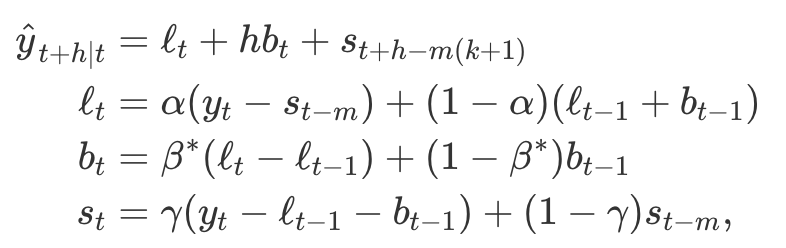

In [ ]:
import math

# Start with this code
###################### Winters Exponential Smoothing #########################
# x <array Tx1>- time series,
# h <scalar> - forecasting delay
# Params <dict> - dictionary with
#    alpha <scalar in [0,1]> - smoothing parameter
#    delts <scalar in [0,1]> - seasonality smoothing parameter

def WintersExponentialSmoothing(x, h, Params):
    T = len(x)
    alpha = Params['alpha']
    gamma = Params['gamma']
    p = Params['seasonality_period']

    FORECAST = [0 for _ in range(T+h)]

    l = float('nan')
    s = [float('nan') for _ in range(p)]

    for cntr in range(T):
        if not math.isnan(x[cntr]):
            if math.isnan(l):
                if cntr + 1 >= p:
                    mean_season = sum(x[cntr + 1 - p:cntr + 1]) / p
                else:
                    mean_season = x[cntr]
                l = mean_season

            if math.isnan(s[cntr % p]):
                s[cntr % p] = x[cntr] - l

            l = alpha * (x[cntr] - s[cntr % p]) + (1 - alpha) * l

            s[cntr % p] = gamma * (x[cntr] - l) + (1 - gamma) * s[cntr % p]

        if not math.isnan(l):
            idx = cntr + h
            season_idx = (idx) % p
            FORECAST[idx] = l + s[season_idx]

    return FORECAST

In [ ]:
n = ts.shape[0]
ts1 = ts.iloc[:n//4, :]
ts2 = ts.iloc[n//4:n//4*2, :]
ts3 = ts.iloc[n//4*2:n//4*3, :]
ts4 = ts.iloc[n//4*3:, :]

In [ ]:
ALPHA = np.round(np.linspace(0.001, 1.0, 10), 3)
GAMMA = np.round(np.linspace(0.001, 1.0, 10), 3)
ESparams = []

for alpha in ALPHA:
  for gamma in GAMMA:
    if gamma <= 1 - alpha:
      ESparams.append({'alpha': alpha, 'gamma': gamma, 'seasonality_period': 90})


In [ ]:
w_FRC_ts = build_forecast(h=1, ts = ts3, alg_name = 'AdditiveWintersExponentialSmoothing', alg_title = 'AdditiveWintersExponentialSmoothing', params = ESparams)

/tmp/ipython-input-3700354462.py:179: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3700354462.py:184: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3700354462.py:188: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3700354462.py:190: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

In [ ]:
# compare ES parameters
qlt_ses = pd.DataFrame(index = ts.columns, columns = w_FRC_ts.keys())

ix = ts3.index
for param_cntr in sorted(qlt_ses.columns):
    frc_ts = w_FRC_ts[param_cntr]
    qlt_ses[param_cntr],_ = qualityMAPE(ts.loc[ix], frc_ts.loc[ix])

qlt_ses[qlt_ses.columns].mean().sort_values().head()

,0
"AdditiveWintersExponentialSmoothing {'alpha': np.float64(0.889), 'gamma': np.float64(0.001), 'seasonality_period': 90}",0.908341
"AdditiveWintersExponentialSmoothing {'alpha': np.float64(0.778), 'gamma': np.float64(0.001), 'seasonality_period': 90}",0.915388
"AdditiveWintersExponentialSmoothing {'alpha': np.float64(0.778), 'gamma': np.float64(0.112), 'seasonality_period': 90}",0.919067
"AdditiveWintersExponentialSmoothing {'alpha': np.float64(0.667), 'gamma': np.float64(0.001), 'seasonality_period': 90}",0.927128
"AdditiveWintersExponentialSmoothing {'alpha': np.float64(0.667), 'gamma': np.float64(0.112), 'seasonality_period': 90}",0.929746


In [ ]:
w_alg_name = qlt_ses[qlt_ses.columns].mean().sort_values().index[0]
plot_ts_forecast(ts.loc[ix], w_FRC_ts[w_alg_name].loc[ix], ts_num=0, alg_title='WEX')

In [ ]:
qualityMAPE(ts.loc[ix], w_FRC_ts[w_alg_name].loc[ix])[0]

,0
EnergyConsumption,0.029567
Temp1,1.079526
Temp2,0.922188
Temp3,0.790910
Temp4,0.944100
Temp5,NaN
Temp6,NaN
Temp7,NaN
Saturday,1.478161
Sunday,1.113933


# 4. Theil-Wage model for TS with linear trend and seasonality (25%)
You need to realize Theil-Wage model and then use it for forecasting the ts.

You can use code from seminars or you can write down your own code using any python lib.


Forecast delay $h=1$ for all point in this task.

* 1) Realize Theil-Wage model
* 2) Split the ts to 4 equal parts: find the best params $\alpha$ (smoothing of level), $\beta$ (smoothing of trend) and $\gamma$ (smoothing of seasonality) for the based on 3-rd part of ts (e.g. if time series includes date from 01Jan2020 till 31Dec2020 then 3rd part will be from 1Jul2020 till 30Sep2020). Use MAPE as a loss function.
* 3) Draw forecast with optimal values $\alpha$, $\beta$ and $\gamma$
* 4) Calculate MAPE loss of the best forecast of the ts based on 4-th part of the ts. Compare it with accuracy of Additive Winters model: is it better than the last one?
* *5) Suggest how can the Theil-Wage model be improved to make accuracy of forecast better?

In [ ]:
n = ts.shape[0]
ts1 = ts.iloc[:n//4, :]
ts2 = ts.iloc[n//4:n//4*2, :]
ts3 = ts.iloc[n//4*2:n//4*3, :]
ts4 = ts.iloc[n//4*3:, :]

In [ ]:
ALPHA = np.round(np.linspace(0.001, 1.0, 5), 3)
BETA = np.round(np.linspace(0.001, 1.0, 5), 3)
GAMMA = np.round(np.linspace(0.001, 1.0, 5), 3)
ESparams = []

for alpha in ALPHA:
  for beta in BETA:
    for gamma in GAMMA:
      if alpha + beta + gamma <= 1:
        ESparams.append({'alpha': alpha, 'beta': beta, 'gamma': gamma, 'seasonality_period': 90})


In [ ]:
FRC_ts = build_forecast(h=1, ts = ts3, alg_name = 'TheilWageExponentialSmoothing', alg_title = 'TheilWageExponentialSmoothing', params = ESparams)

/tmp/ipython-input-3700354462.py:216: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3700354462.py:218: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3700354462.py:224: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3700354462.py:230: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

In [ ]:
# compare ES parameters
qlt_ses = pd.DataFrame(index = ts.columns, columns = FRC_ts.keys())

ix = ts3.index
for param_cntr in sorted(qlt_ses.columns):
    frc_ts = FRC_ts[param_cntr]
    qlt_ses[param_cntr],_ = qualityMAPE(ts.loc[ix], frc_ts.loc[ix])

qlt_ses[qlt_ses.columns].mean().sort_values().head()

,0
"TheilWageExponentialSmoothing {'alpha': np.float64(0.75), 'beta': np.float64(0.001), 'gamma': np.float64(0.001), 'seasonality_period': 90}",0.580988
"TheilWageExponentialSmoothing {'alpha': np.float64(0.5), 'beta': np.float64(0.001), 'gamma': np.float64(0.001), 'seasonality_period': 90}",0.612920
"TheilWageExponentialSmoothing {'alpha': np.float64(0.5), 'beta': np.float64(0.251), 'gamma': np.float64(0.001), 'seasonality_period': 90}",0.647524
"TheilWageExponentialSmoothing {'alpha': np.float64(0.5), 'beta': np.float64(0.001), 'gamma': np.float64(0.251), 'seasonality_period': 90}",0.660689
"TheilWageExponentialSmoothing {'alpha': np.float64(0.251), 'beta': np.float64(0.001), 'gamma': np.float64(0.001), 'seasonality_period': 90}",0.668228


In [ ]:
alg_name = qlt_ses[qlt_ses.columns].mean().sort_values().index[0]
plot_ts_forecast(ts.loc[ix], FRC_ts[alg_name].loc[ix], ts_num=0, alg_title='WEX')

In [ ]:
 pd.concat([qualityMAPE(ts.loc[ix], FRC_ts[alg_name].loc[ix])[0], qualityMAPE(ts.loc[ix], w_FRC_ts[w_alg_name].loc[ix])[0]], axis=1)

,0,1
EnergyConsumption,0.017129,0.029567
Temp1,0.675906,1.079526
Temp2,0.512557,0.922188
Temp3,0.503855,0.790910
Temp4,0.515967,0.944100
Temp5,NaN,NaN
Temp6,NaN,NaN
Temp7,NaN,NaN
Saturday,1.000309,1.478161
Sunday,0.841194,1.113933


# 5. Non-additive model of ES (25%)
You need to realize some ES-model that include non-addive component (or multiplicative trend or multiplicative component) or/and damped-trend component and then use it for forecasting of the ts

You can use code from seminars or you can write down your own code using any python lib.

Forecast delay $h=1$ for all point in this task.

* 1) Realize one of following ES models: ESM(A,M) (t.e. Holt-Winters model), ESM(Ad,M), ESM(M,A), ESM(M,M), ESM(Md,M) model.
* 2) Split the ts to 4 equal parts: find the best params $\alpha$ (smoothing of level)/$\beta$ (smoothing of trend)/$\gamma$ (smoothing of seasonality) for the based on 3-rd part of ts (e.g. if time series includes date from 01Jan2020 till 31Dec2020 then 3rd part will be from 1Jul2020 till 30Sep2020). Use MAPE as a loss function.
Note: if you seelct damped trend model then you can set  $\phi$ value expertly (say $0.98$). (Loss function should be the same as in task 2.)
* 3) Draw forecast with optimal values of it's params.
* 4) Calculate accuracy of the forecast of TS based on 4-th part of the ts. Compare it with accuracy of Additive Winters model and Theil-Wage model, which model is the best?
* 5) Will be results the same if forecas horizon is different (h = seasonlaity period of data)? Please give reasons for your answer.

In [ ]:
n = ts.shape[0]
ts1 = ts.iloc[:n//4, :]
ts2 = ts.iloc[n//4:n//4*2, :]
ts3 = ts.iloc[n//4*2:n//4*3, :]
ts4 = ts.iloc[n//4*3:, :]

In [ ]:
ALPHA = np.round(np.linspace(0.001, 1.0, 10), 3)
BETA = np.round(np.linspace(0.001, 1.0, 10), 3)
ESparams = []

for alpha in ALPHA:
  for beta in BETA:
      if alpha + beta <= 1:
        ESparams.append({'alpha': alpha, 'beta': beta, 'AdaptationPeriod': 90})


In [ ]:
FRC_ts = build_forecast(h=1, ts = ts3, alg_name = 'HoltExponentialSmoothing', alg_title = 'HoltExponentialSmoothing', params = ESparams)

/tmp/ipython-input-3957989220.py:121: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3957989220.py:123: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3957989220.py:124: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3957989220.py:133: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

In [ ]:
# compare ES parameters
qlt_ses = pd.DataFrame(index = ts.columns, columns = FRC_ts.keys())

ix = ts3.index
for param_cntr in sorted(qlt_ses.columns):
    frc_ts = FRC_ts[param_cntr]
    qlt_ses[param_cntr],_ = qualityMAPE(ts.loc[ix], frc_ts.loc[ix])

qlt_ses[qlt_ses.columns].mean().sort_values().head()

,0
"HoltExponentialSmoothing {'alpha': np.float64(0.889), 'beta': np.float64(0.001), 'AdaptationPeriod': 90}",0.587764
"HoltExponentialSmoothing {'alpha': np.float64(0.778), 'beta': np.float64(0.112), 'AdaptationPeriod': 90}",0.590854
"HoltExponentialSmoothing {'alpha': np.float64(0.778), 'beta': np.float64(0.001), 'AdaptationPeriod': 90}",0.599871
"HoltExponentialSmoothing {'alpha': np.float64(0.667), 'beta': np.float64(0.112), 'AdaptationPeriod': 90}",0.602866
"HoltExponentialSmoothing {'alpha': np.float64(0.667), 'beta': np.float64(0.001), 'AdaptationPeriod': 90}",0.615112


In [ ]:
alg_name = qlt_ses[qlt_ses.columns].mean().sort_values().index[0]
plot_ts_forecast(ts.loc[ix], FRC_ts[alg_name].loc[ix], ts_num=0, alg_title='WEX')

In [ ]:
qualityMAPE(ts.loc[ix], FRC_ts[alg_name].loc[ix])[0]

,0
EnergyConsumption,0.017342
Temp1,0.667302
Temp2,0.529565
Temp3,0.552937
Temp4,0.511104
Temp5,NaN
Temp6,NaN
Temp7,NaN
Saturday,1.000017
Sunday,0.836082
